# INSID3 medical benchmark

Training-free in-context segmentation on three domains INSID3 has not been scored on: **colon polyp** ([Kvasir-SEG](#ref-jha2020)), **kidney tumor** ([KiPA22](#ref-he2021)), **cardiac LV** ([ACDC](#ref-bernard2018)). The project asks whether the published medical result holds on these domains, whether a medical-pretrained encoder improves one-shot INSID3, and how far that number still sits behind medically supervised MedSAM2.

This project has three aims.

1. **Transfer.** Does INSID3 remain a strong training-free one-shot method when the domain is no longer ISIC or chest X-ray — endoscopy, abdominal CT, and cardiac MRI, with targets that range from well-outlined anatomy to small, appearance-defined lesions? “Strong” is measured against Matcher and GF-SAM on the same episodes, and against the paper anchors: ISIC **54.4** mIoU and CXR lung **78.8** mIoU ([Cuttano et al., CVPR 2026](#ref-cuttano2026)).
2. **Encoder.** On kidney tumor CT, does replacing DINOv3 with a CT-pretrained frozen encoder (FlexiCT-2D) raise one-shot mIoU?
3. **Supervision gap.** How far is that training-free number from box-prompted MedSAM2 zero-shot on the same slices? That comparison is a reference, not a same-paradigm contest.

The evaluation protocol follows the INSID3 lung and ISIC experiments:

- 600 independently sampled one-shot episodes per domain
- For reproducibility, episode sampling held fixed
- DINOv3 ViT-L with input resolution 768 px
- INSID3 default inference settings (τ = 0.6, α = 0.2, s = 500), with no per-domain hyperparameter tuning
- No CRF mask refinement. Predicted masks are bilinearly upsampled from the patch grid to the original image size. The paper’s main tables optionally apply a Dense Gaussian CRF as post-processing ([Cuttano et al., CVPR 2026](#ref-cuttano2026)); this study does not.

## Table of contents

0. [Setup](#sec-setup)
1. [Download / preprocess benchmark datasets](#sec-data)
2. [Run in-context evaluation](#sec-eval)
2b. [Training-free baselines (GF-SAM / Matcher)](#sec-tier-b)
2c. [FlexiCT-2D encoder swap](#sec-flexict)
2d. [MedSAM2 box-prompted reference](#sec-tier-c)
3. [Results](#sec-report)
4. [Inspect episodes](#sec-inspect)
5. [References](#sec-refs)

<h2 id="sec-setup">0. Setup</h2>

In [7]:
REPO_URL = "https://github.com/gary8564/insid3-medical-benchmark.git"
DRIVE_ROOT = "/content/drive/MyDrive/insid3-medical-benchmark"
REPO_DIR = "/content/insid3-medical-benchmark"
MODEL_SIZE = "large"
IMAGE_SIZE = 768
SEED = 0
PREVIEW = None  # e.g. 8 to test the pipeline; None = all 600
VIT_L = "dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"
DOMAINS = ("polyp", "kidney_tumor", "cardiac")

In [10]:
from google.colab import drive

drive.mount("/content/drive")

from pathlib import Path

drive_root = Path(DRIVE_ROOT)
for sub in ("processed", "pretrain", "results"):
    (drive_root / sub).mkdir(parents=True, exist_ok=True)
print("Drive layout:", drive_root)
print("ViT-L present:", (drive_root / "pretrain" / VIT_L).is_file())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive layout: /content/drive/MyDrive/insid3-medical-benchmark
ViT-L present: True


In [11]:
from pathlib import Path

repo = Path(REPO_DIR)
if not (repo / ".git").is_dir():
    !git clone --recurse-submodules {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --ff-only
    !git -C {REPO_DIR} submodule update --init --recursive

assert (repo / "third_party" / "INSID3" / "models" / "insid3.py").is_file(), (
    f"INSID3 submodule missing at {repo / 'third_party' / 'INSID3'}; clone with --recurse-submodules"
)
for name, marker in (
    ("GF-SAM", "matcher/GFSAM.py"),
    ("Matcher", "matcher/Matcher.py"),
    ("FlexiCT", "flexi_ct/__init__.py"),
    ("MedSAM2", "sam2"),
):
    path = repo / "third_party" / name / marker
    if not path.exists():
        print(f"warning: {name} submodule missing at {path}; Phase 6–8 need git submodule update --init --recursive")
%cd {REPO_DIR}

remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 17 (delta 13), reused 16 (delta 12), pack-reused 0 (from 0)
Unpacking objects: 100% (17/17), 5.37 KiB | 37.00 KiB/s, done.
From https://github.com/gary8564/insid3-medical-benchmark
   c685161..aaf959b  main       -> origin/main
Updating c685161..aaf959b
Fast-forward
 README.md                        |   2 +-
 docs/data.md                     |   4 +-
 notebooks/eval_insid3.ipynb      | 289 ++++++++++++++++++++++++++-------------
 src/backbones/dinov3_backbone.py |  21 +--
 src/datasets/episodes.py         |  14 +-
 src/run_insid3.py                |  25 +---
 tests/test_insid3_forward.py     |   4 +-
 tests/test_loaders.py            |  12 +-
 tests/test_run_insid3_dry_run.py |  25 ++--
 9 files changed, 222 insertions(+), 174 deletions(-)
/content/insid3-medical-benchmark


In [12]:
# Colab already has torch, numpy, pillow, matplotlib, tqdm, scikit-learn.
# Do not `uv sync` or `uv pip install .[torch]`: pyproject pins CPython 3.10
# and would download a second torch on top of the runtime CUDA build.
# Do not `pip install -r third_party/*/requirements.txt`.
%pip install -q uv
!uv pip install --system -q nibabel einops huggingface_hub pycocotools
!uv pip install --system -q opencv-python-headless pot omegaconf iopath timm scipy hydra-core

<div style="background:#fff8e1;border-left:4px solid #f9a825;padding:0.8em 1em;margin:1em 0;color:#4a3c00;">
<strong>⚠️ DINOv3 access required</strong>. INSID3 uses a frozen DINOv3 encoder. Request a grant at <a href="https://github.com/facebookresearch/dinov3" style="color:#4a3c00;"><strong>facebookresearch/dinov3</strong></a>. Weights are gated and are not in this repo.
</div>

After approval, download **ViT-L** and place it in `pretrain/` at the repo root `pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth`

In [13]:
from pathlib import Path

# pretrain/ is gitignored, so the clone does not create it. curl cannot.
drive_weights = Path(DRIVE_ROOT) / "pretrain" / VIT_L
repo_weights = Path(REPO_DIR) / "pretrain" / VIT_L
repo_weights.parent.mkdir(parents=True, exist_ok=True)
drive_weights.parent.mkdir(parents=True, exist_ok=True)

# Prefer an existing Drive copy (survives Colab runtime resets).
if drive_weights.is_file() and drive_weights.stat().st_size > 0:
    print("using Drive weights:", drive_weights, drive_weights.stat().st_size)
else:
    # Write to local disk first — Drive FUSE often fails mid-curl on ~1.1 GB files.
    !curl -L --fail --retry 3 --output {repo_weights} "https://dinov3.llamameta.net/dinov3_vitl16/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoid25uZnl5cHUxb3Z0NWlza3hieXpmZzY3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODY3OTc2MTF9fX1dfQ__&Signature=pdJdVI46bVY7BpoCVj3Yi-c0GrOmusbgQ2QuQiFDRvhfXF1baD0EvSKkKqL3MDZoG70k8xJ7-kcTRYlL4y29dciSE%7EqasX0v5GPGMqIrQ7qOH2V0JVwQ-OX79V6n0X-B2SZKdlLZkSd%7E89iMnOOj9btMd30me4s1Vk%7ERjvYfhwwdHv7WxvRSKrmq6YLguhzxgw8%7EhITJuiju2ImwEjj47OJOs4SHCQxPS0QRcqIoC5sBHcYtRQg9gr%7E5frdwGyJxJa0JK3E91OdZt8PzoTQXzqgSbeY9feSukZiAb1YXY%7EeBHSLqqSqMZGTZtJ-mzPSfY3p98mRJI%7ET1SJROidqTAQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1052263980722882"
    assert repo_weights.is_file() and repo_weights.stat().st_size > 1_000_000_000, repo_weights
    print("copying to Drive (keeps weights after runtime reset)...")
    import shutil
    shutil.copy2(repo_weights, drive_weights)

if not repo_weights.is_file():
    if repo_weights.exists() or repo_weights.is_symlink():
        repo_weights.unlink()
    repo_weights.symlink_to(drive_weights)
print("using", repo_weights, "size", repo_weights.stat().st_size)

using Drive weights: /content/drive/MyDrive/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth 1213050671
using /content/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth size 1213050671


In [14]:
from pathlib import Path

weights = Path(REPO_DIR) / "pretrain" / VIT_L
assert weights.is_file() and weights.stat().st_size > 0, (
    f"Missing {weights}. After DINOv3 access is granted, place {VIT_L} in pretrain/."
)
print("using", weights)

using /content/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth


In [ ]:
# Public Phase 6–8 weights (DINOv2 + SAM ViT-H). FlexiCT is a manual Drive file.
from pathlib import Path
import shutil

drive_pretrain = Path(DRIVE_ROOT) / "pretrain"
repo_pretrain = Path(REPO_DIR) / "pretrain"
drive_pretrain.mkdir(parents=True, exist_ok=True)
repo_pretrain.mkdir(parents=True, exist_ok=True)

!python src/data/download_weights.py --dest {drive_pretrain} --dinov2 --sam

for src in drive_pretrain.iterdir():
    if not src.is_file():
        continue
    dest = repo_pretrain / src.name
    if dest.is_file() or dest.is_symlink():
        continue
    dest.symlink_to(src)
    print("linked", dest, "→", src)

for name in ("dinov2_vitl14_pretrain.pth", "sam_vit_h_4b8939.pth"):
    path = repo_pretrain / name
    print(f"{name}: {'ok' if path.is_file() else 'MISSING'} ({path.stat().st_size if path.is_file() else 0} bytes)")
print("FlexiCT-2D (Phase 7): copy flexict_2d_teacher.pth into Drive pretrain/ from the FlexiCT README Google Drive link.")
print("MedSAM2 (Phase 8): run the 2d cell, or: python src/data/download_weights.py --dest", drive_pretrain, "--medsam2")


<h2 id="sec-data">1. Download / preprocess benchmark datasets</h2>

Build the 2D cache used for in-context eval:

- **[Kvasir-SEG](#ref-jha2020)** is a 2D colonoscopy set with paired polyp masks.
- **[KiPA22](#ref-he2021)** is a 3D abdominal CT challenge with kidney, vessels, and tumor labels.
- **[ACDC](#ref-bernard2018)** is a 3D cine cardiac MRI challenge with RV, myocardium, and LV cavity labels.

[Kvasir-SEG](#ref-jha2020) is already 2D, so each endoscopy frame is kept with its binary polyp mask. [KiPA22](#ref-he2021) and [ACDC](#ref-bernard2018) are volumes, so each case is preprocessed to one image–mask PNG.

For [KiPA22](#ref-he2021), the axial slice with the **most tumor** voxels (other structures become background) is kept. For [ACDC](#ref-bernard2018), end-diastole is read from `Info.cfg`, then the short-axis slice with the **largest LV cavity**.

<div style="background:#fff8e1;border-left:4px solid #f9a825;padding:0.8em 1em;margin:1em 0;color:#4a3c00;">
<strong>⚠️ Hugging Face login required</strong> for [KiPA22](#ref-he2021) and [ACDC](#ref-bernard2018).
</div>

In [15]:
from huggingface_hub import login, notebook_login
import os

# Uses Colab secrets if you added HF_TOKEN; otherwise a login prompt.
try:
    from google.colab import userdata
    login(token=userdata.get("hf_token"))
except Exception:
    notebook_login()

In [16]:
from src.datasets.pairing import IMAGE_EXTENSIONS

processed = Path(DRIVE_ROOT) / "processed"

def _n_images(domain: str) -> int:
    folder = processed / domain / "images"
    if not folder.is_dir():
        return 0
    return sum(
        1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

In [17]:
from pathlib import Path

missing = [name for name in DOMAINS if _n_images(name) == 0]
print("missing domains:", missing or "none")
if missing:
    processed_root = str(processed)
    datasets = " ".join(missing)
    !python src/data/prepare.py --processed-root {processed_root} --datasets {datasets}

missing domains: none


In [18]:
from pathlib import Path
import shutil

processed = Path(DRIVE_ROOT) / "processed"
counts = {name: _n_images(name) for name in DOMAINS}
for name, n in counts.items():
    print(f"{name}: {n} images")

assert counts["polyp"] >= 900, (
    "polyp cache empty — Kvasir images are .jpg, not .png. "
    "Re-run prepare only if Drive processed/polyp/images is actually empty."
)
assert counts["kidney_tumor"] >= 70, "kidney_tumor cache empty — re-run prepare (needs HF login)."
assert counts["cardiac"] >= 100, "cardiac cache empty — re-run prepare (needs HF login)."

raw = Path(REPO_DIR) / "data" / "raw"
if raw.exists():
    shutil.rmtree(raw)
    print("removed local raw downloads; processed cache is on Drive")

polyp: 1000 images
kidney_tumor: 70 images
cardiac: 100 images


<h2 id="sec-eval">2. Run in-context evaluation</h2>

In [19]:
import json
from pathlib import Path

for dataset in DOMAINS:
    log = f"/tmp/insid3_episodes_{dataset}.json"
    !python src/run_insid3.py --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results/{dataset} \
      --dry-run > {log}
    episodes_path = Path(DRIVE_ROOT) / "results" / dataset / "episodes.json"
    n = len(json.loads(episodes_path.read_text())) if episodes_path.is_file() else 0
    print(f"{dataset}: {n} episodes → {episodes_path}")

polyp: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/polyp/episodes.json
kidney_tumor: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/kidney_tumor/episodes.json
cardiac: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/episodes.json


In [20]:
import json
from pathlib import Path

# False: skip a domain whose metrics.json already matches this protocol.
# True: run inference again even if the results under the same evaluation settings exist.
OVERWRITE = False

preview = f"--preview {PREVIEW}" if PREVIEW is not None else ""
expected_n = PREVIEW if PREVIEW is not None else 600


def _is_complete(name: str) -> bool:
    path = Path(DRIVE_ROOT) / "results" / name / "metrics.json"
    if not path.is_file():
        return False
    row = json.loads(path.read_text())
    return (
        int(row.get("n", 0)) == int(expected_n)
        and row.get("model_size") == MODEL_SIZE
        and int(row.get("image_size", 0)) == int(IMAGE_SIZE)
        and int(row.get("seed", -1)) == int(SEED)
    )


for dataset in DOMAINS:
    path = Path(DRIVE_ROOT) / "results" / dataset / "metrics.json"
    if _is_complete(dataset) and not OVERWRITE:
        row = json.loads(path.read_text())
        print(f"{dataset}: skip (n={row['n']}  mIoU={row['mIoU']:.3f}  → {path})")
        continue
    log = f"/tmp/insid3_eval_{dataset}.log"
    print(f"{dataset}: running → {log}")
    !python src/run_insid3.py --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results/{dataset} \
      --model-size {MODEL_SIZE} --image-size {IMAGE_SIZE} --seed {SEED} --device cuda \
      {preview} > {log}
    row = json.loads(path.read_text())
    print(
        f"{dataset}: n={row['n']}  mIoU={row['mIoU']:.3f}  "
        f"Dice={row['Dice']:.3f}  → {path}"
    )

print("\nDrive cache:")
for name in DOMAINS:
    path = Path(DRIVE_ROOT) / "results" / name / "metrics.json"
    if not path.is_file():
        print(f"  {name}: missing")
        continue
    row = json.loads(path.read_text())
    print(f"  {name}: n={row['n']}  mIoU={row['mIoU']:.3f}  Dice={row['Dice']:.3f}")

polyp: running → /tmp/insid3_eval_polyp.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
polyp: 100% 600/600 [15:04<00:00,  1.51s/it]
polyp: n=600  mIoU=0.678  Dice=0.762  → /content/drive/MyDrive/insid3-medical-benchmark/results/polyp/metrics.json
kidney_tumor: running → /tmp/insid3_eval_kidney_tumor.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
kidney_tumor: 100% 600/600 [03:40<00:00,  2.72it/s]
kidney_tumor: n=600  mIoU=0.306  Dice=0.432  → /content/drive/MyDrive/insid3-medical-benchmark/results/kidney_tumor/metrics.json
cardiac: running → /tmp/insid3_eval_cardiac.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
cardiac: 100% 600/600 [02:27<00:00,  4.07it/s]
cardiac: n=600  mIoU=0.119  Dice=0.200  → /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/metrics.json

Drive cache:
  polyp: n=600  mIoU=0.678  Dice=0.762
  kidney_tumor: n=600  mIoU=0.306  Dice=0.432
  cardiac: n=600  mIoU=0.

<h2 id="sec-tier-b">2b. Training-free baselines (GF-SAM / Matcher)</h2>

Same 600 Phase 3 episodes, training-free 1-shot mask prompt. This is the Q1 comparison (tier B). Do not write into `results/polyp/` — those folders are the INSID3 snapshot.

Smoke first: set `PREVIEW = 1` in the setup cell (or pass `--preview 1` below), confirm the pred PNG is the original Kvasir/CT/MRI size, then `--preview 8`, then the full 600. GF-SAM first (faster). Matcher is ~9 s/image.

Run **one method × one domain per session** if the VM dies. Skip-if-complete reads `results/<method>/<dataset>/metrics.json`.

In [ ]:
import json
from pathlib import Path

# False: skip a method×domain whose metrics.json already matches this protocol.
OVERWRITE_TIER_B = False
# "gfsam" | "matcher" — run Matcher only after GF-SAM has numbers (it is much slower).
TIER_B_METHOD = "gfsam"
TIER_B_DOMAINS = DOMAINS  # ("polyp", "kidney_tumor", "cardiac")
preview = f"--preview {PREVIEW}" if PREVIEW is not None else ""
expected_n = PREVIEW if PREVIEW is not None else 600
image_size = 1024 if TIER_B_METHOD == "gfsam" else 518


def _tier_b_complete(method: str, name: str) -> bool:
    path = Path(DRIVE_ROOT) / "results" / method / name / "metrics.json"
    if not path.is_file():
        return False
    row = json.loads(path.read_text())
    return (
        int(row.get("n", 0)) == int(expected_n)
        and row.get("method") == method
        and int(row.get("image_size", 0)) == int(image_size)
        and int(row.get("seed", -1)) == int(SEED)
    )


for dataset in TIER_B_DOMAINS:
    out = Path(DRIVE_ROOT) / "results" / TIER_B_METHOD / dataset
    path = out / "metrics.json"
    if _tier_b_complete(TIER_B_METHOD, dataset) and not OVERWRITE_TIER_B:
        row = json.loads(path.read_text())
        print(f"{TIER_B_METHOD}/{dataset}: skip (n={row['n']}  mIoU={row['mIoU']:.3f}  → {path})")
        continue
    log = f"/tmp/{TIER_B_METHOD}_{dataset}.log"
    print(f"{TIER_B_METHOD}/{dataset}: running → {log}")
    overwrite = "--overwrite" if OVERWRITE_TIER_B else ""
    !python -m src.methods.{TIER_B_METHOD} --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results/{TIER_B_METHOD} \
      --episodes-json {DRIVE_ROOT}/results/{dataset}/episodes.json \
      --dinov2-weights {DRIVE_ROOT}/pretrain/dinov2_vitl14_pretrain.pth \
      --sam-weights {DRIVE_ROOT}/pretrain/sam_vit_h_4b8939.pth \
      --image-size {image_size} --seed {SEED} --device cuda \
      {preview} {overwrite} > {log}
    row = json.loads(path.read_text())
    print(f"{TIER_B_METHOD}/{dataset}: n={row['n']}  mIoU={row['mIoU']:.3f}  Dice={row['Dice']:.3f}  → {path}")


<h2 id="sec-flexict">2c. FlexiCT-2D encoder swap</h2>

Do **not** start until 2b has Matcher + GF-SAM numbers on all three domains. KiPA only for the required table (debias on, then off). Same Phase 3 episodes, canvas 768, patch size 16. Polyp is out of scope. ACDC is an optional out-of-modality probe.

Copy `flexict_2d_teacher.pth` into Drive `pretrain/` first (Google Drive link in the FlexiCT README). Smoke `--preview 1`, then 8, then 600.

In [ ]:
import json
from pathlib import Path

# Required: kidney_tumor, debiased on then off. Optional probe: cardiac.
FLEXICT_DATASET = "kidney_tumor"
FLEXICT_DEBIASED = True  # False writes results/flexict2d/nodebiased/
OVERWRITE_FLEXICT = False
preview = f"--preview {PREVIEW}" if PREVIEW is not None else ""
expected_n = PREVIEW if PREVIEW is not None else 600
condition = "debiased" if FLEXICT_DEBIASED else "nodebiased"
out = Path(DRIVE_ROOT) / "results" / "flexict2d" / condition / FLEXICT_DATASET
path = out / "metrics.json"
flexict_ckpt = Path(DRIVE_ROOT) / "pretrain" / "flexict_2d_teacher.pth"
assert flexict_ckpt.is_file(), f"Missing {flexict_ckpt}. Copy the FlexiCT-2D teacher weights to Drive pretrain/."


def _flexict_complete() -> bool:
    if not path.is_file():
        return False
    row = json.loads(path.read_text())
    return (
        int(row.get("n", 0)) == int(expected_n)
        and row.get("backbone") == "flexict2d"
        and bool(row.get("debiased")) == bool(FLEXICT_DEBIASED)
        and int(row.get("image_size", 0)) == 768
    )


if _flexict_complete() and not OVERWRITE_FLEXICT:
    row = json.loads(path.read_text())
    print(f"flexict2d/{condition}/{FLEXICT_DATASET}: skip (n={row['n']}  mIoU={row['mIoU']:.3f}  → {path})")
else:
    log = f"/tmp/flexict_{condition}_{FLEXICT_DATASET}.log"
    print(f"flexict2d/{condition}/{FLEXICT_DATASET}: running → {log}")
    debiased_flag = "" if FLEXICT_DEBIASED else "--no-debiased"
    overwrite = "--overwrite" if OVERWRITE_FLEXICT else ""
    !python -m src.methods.insid3 --backbone flexict2d --dataset {FLEXICT_DATASET} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results/flexict2d/{condition} \
      --episodes-json {DRIVE_ROOT}/results/{FLEXICT_DATASET}/episodes.json \
      --flexict-weights {flexict_ckpt} --flexict-patch-size 16 \
      --image-size 768 --seed {SEED} --device cuda \
      {debiased_flag} {preview} {overwrite} > {log}
    row = json.loads(path.read_text())
    print(f"flexict2d/{condition}/{FLEXICT_DATASET}: n={row['n']}  mIoU={row['mIoU']:.3f}  Dice={row['Dice']:.3f}  → {path}")


<h2 id="sec-tier-c">2d. MedSAM2 box-prompted reference</h2>

Supervision-gap reference (tier C), not a Q1 baseline. The prompt is a **tight box from the target GT** (`max_shift=0`), and the model was trained on labelled medical masks. One 2D frame only — no `propagate_in_video`. Never put these numbers in the INSID3 / Matcher / GF-SAM table.

Download `MedSAM2_latest.pt` once, then smoke `--preview 1` / `8`, then 600 on all three domains.

In [ ]:
import json
from pathlib import Path

OVERWRITE_MEDSAM2 = False
MEDSAM2_DOMAINS = DOMAINS
preview = f"--preview {PREVIEW}" if PREVIEW is not None else ""
expected_n = PREVIEW if PREVIEW is not None else 600
medsam2_ckpt = Path(DRIVE_ROOT) / "pretrain" / "MedSAM2_latest.pt"
if not medsam2_ckpt.is_file():
    !python src/data/download_weights.py --dest {DRIVE_ROOT}/pretrain --medsam2
    repo_ckpt = Path(REPO_DIR) / "pretrain" / "MedSAM2_latest.pt"
    if not repo_ckpt.exists():
        repo_ckpt.symlink_to(medsam2_ckpt)
assert medsam2_ckpt.is_file(), f"Missing {medsam2_ckpt}"


def _medsam2_complete(name: str) -> bool:
    path = Path(DRIVE_ROOT) / "results" / "medsam2" / name / "metrics.json"
    if not path.is_file():
        return False
    row = json.loads(path.read_text())
    return (
        int(row.get("n", 0)) == int(expected_n)
        and row.get("method") == "medsam2"
        and row.get("prompt") == "box_from_gt"
        and int(row.get("image_size", 0)) == 512
    )


for dataset in MEDSAM2_DOMAINS:
    path = Path(DRIVE_ROOT) / "results" / "medsam2" / dataset / "metrics.json"
    if _medsam2_complete(dataset) and not OVERWRITE_MEDSAM2:
        row = json.loads(path.read_text())
        print(f"medsam2/{dataset}: skip (n={row['n']}  mIoU={row['mIoU']:.3f}  → {path})")
        continue
    log = f"/tmp/medsam2_{dataset}.log"
    print(f"medsam2/{dataset}: running → {log}")
    overwrite = "--overwrite" if OVERWRITE_MEDSAM2 else ""
    !python -m src.methods.medsam2 --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results/medsam2 \
      --episodes-json {DRIVE_ROOT}/results/{dataset}/episodes.json \
      --checkpoint {medsam2_ckpt} \
      --seed {SEED} --device cuda \
      {preview} {overwrite} > {log}
    row = json.loads(path.read_text())
    print(f"medsam2/{dataset}: n={row['n']}  mIoU={row['mIoU']:.3f}  Dice={row['Dice']:.3f}  → {path}")


<h2 id="sec-report">3. Results</h2>

One-shot INSID3 with frozen DINOv3. These tasks are not clinical equivalents of INSID paper’s ISIC or chest X-ray experiments.

| Domain | Image | Target |
|---|---|---|
| Colon polyp ([Kvasir-SEG](#ref-jha2020)) | endoscopy | mucosal lesion |
| Kidney tumor ([KiPA22](#ref-he2021)) | axial CT | small tumor focus |
| Cardiac LV ([ACDC](#ref-bernard2018)) | short-axis cine MRI | LV cavity |

In [21]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.datasets.episodes import load_paired_index

DOMAIN_META = {
    "polyp": {"title": "Colon polyp", "modality": "endoscopy"},
    "kidney_tumor": {"title": "Kidney tumor", "modality": "CT"},
    "cardiac": {"title": "Cardiac LV", "modality": "MRI"},
}
HEADLINE = {"seed": 0, "model_size": "large", "image_size": 768, "n": 600}
GT_GREEN = (0.15, 0.8, 0.35)
PRED_BLUE = (0.2, 0.45, 0.95)

results_root = Path(DRIVE_ROOT) / "results"
processed_root = Path(DRIVE_ROOT) / "processed"
fig_dir = results_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)


def _overlay(image, mask, color):
    out = image.astype(np.float32).copy()
    tint = np.array(color, dtype=np.float32) * 255.0
    out[mask] = 0.55 * out[mask] + 0.45 * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def _spearman(x, y):
    """Rank correlation: does IoU rise when the target is larger?"""
    if len(x) < 3:
        return float("nan")
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx.astype(float), ry.astype(float))[0, 1])


def _load_domain(name):
    path = results_root / name / "metrics.json"
    if not path.is_file():
        return None
    payload = json.loads(path.read_text())
    items = list(payload.get("items") or [])
    ious = np.array([float(row["IoU"]) for row in items], dtype=float)
    flags = [
        f"{key}={payload.get(key) if key != 'n' else int(payload.get('n', len(items)))} (expected {expected})"
        for key, expected in HEADLINE.items()
        if (int(payload.get("n", len(items))) if key == "n" else payload.get(key)) != expected
    ]
    return {
        "payload": payload,
        "items": items,
        "ious": ious,
        "ranked": sorted(items, key=lambda row: row["IoU"], reverse=True),
        "flags": flags,
    }


def _show_triple(name, row, pairs, caption):
    pred_path = results_root / name / "preds" / f"{int(row['episode_index']):04d}_{row['target_id']}.png"
    ref_img, ref_mask = pairs[row["reference_ids"][0]]
    tgt_img, tgt_mask = pairs[row["target_id"]]
    ref_np = np.array(Image.open(ref_img).convert("RGB"))
    tgt_np = np.array(Image.open(tgt_img).convert("RGB"))
    ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
    gt = np.array(Image.open(tgt_mask).convert("L")) > 0
    pred = np.array(Image.open(pred_path).convert("L")) > 0 if pred_path.is_file() else np.zeros_like(gt)
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
    axes[0].imshow(_overlay(ref_np, ref_gt, GT_GREEN))
    axes[0].set_title("Reference + mask")
    axes[1].imshow(_overlay(tgt_np, gt, GT_GREEN))
    axes[1].set_title("Target + GT")
    axes[2].imshow(_overlay(tgt_np, pred, PRED_BLUE))
    axes[2].set_title("Target + prediction")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{DOMAIN_META[name]['title']} ({caption} IoU = {row['IoU']:.3f})", fontsize=11)
    fig.savefig(fig_dir / f"{name}_{caption}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


domains = {name: _load_domain(name) for name in DOMAINS}
found = [name for name, row in domains.items() if row is not None]
missing = [name for name in DOMAINS if domains[name] is None]
if missing:
    print("Missing:", ", ".join(missing), ". Run section 2 first.")
if not found:
    raise FileNotFoundError(f"no metrics.json under {results_root}")

print(f"{'domain':<16} {'n':>5} {'mIoU':>7} {'Dice':>7} {'median':>7}")
for name in found:
    row = domains[name]
    p = row["payload"]
    print(
        f"{DOMAIN_META[name]['title']:<16} {int(p['n']):5d} "
        f"{100 * p['mIoU']:6.1f}  {100 * p['Dice']:6.1f}  {100 * np.median(row['ious']):6.1f}"
    )
for name in found:
    if domains[name]["flags"]:
        print(f"protocol {name}:", "; ".join(domains[name]["flags"]))

domain               n    mIoU    Dice  median
Colon polyp        600   67.8    76.2    81.0
Kidney tumor       600   30.6    43.2    28.0
Cardiac LV         600   11.9    20.0     7.6


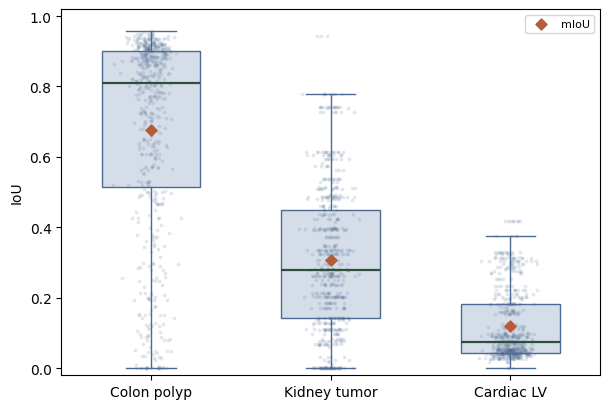

In [22]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
data = [domains[name]["ious"] for name in found]
ax.boxplot(
    data,
    tick_labels=[DOMAIN_META[name]["title"] for name in found],
    whis=1.5,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops={"color": "#2F4F3E", "linewidth": 1.6},
    boxprops={"facecolor": "#D5DDE8", "edgecolor": "#4C6A92"},
    whiskerprops={"color": "#4C6A92"},
    capprops={"color": "#4C6A92"},
)
rng = np.random.default_rng(0)
for i, name in enumerate(found, start=1):
    ious = domains[name]["ious"]
    ax.scatter(rng.normal(i, 0.055, size=len(ious)), ious, s=7, alpha=0.16, c="#4C6A92", linewidths=0, zorder=2)
    ax.scatter([i], [float(np.mean(ious))], marker="D", s=32, c="#B85C38", zorder=3, label="mIoU" if i == 1 else None)
ax.set_ylabel("IoU")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8, frameon=True, loc="upper right")
fig.tight_layout()
fig.savefig(fig_dir / "iou_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

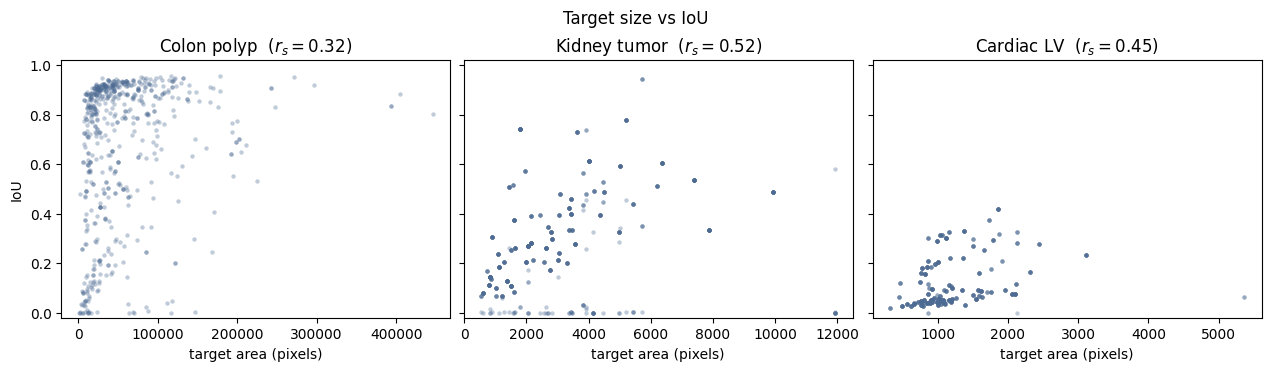

In [23]:
fig, axes = plt.subplots(1, len(found), figsize=(4.2 * len(found), 3.6), constrained_layout=True, sharey=True)
if len(found) == 1:
    axes = [axes]
for ax, name in zip(axes, found):
    pairs = load_paired_index(processed_root, name)
    areas = np.array(
        [(np.array(Image.open(pairs[item["target_id"]][1]).convert("L")) > 0).sum() for item in domains[name]["items"]],
        dtype=float,
    )
    ious = domains[name]["ious"]
    ax.scatter(areas, ious, s=10, alpha=0.35, c="#4C6A92", linewidths=0)
    ax.set_title(fr"{DOMAIN_META[name]['title']}  ($r_s={_spearman(areas, ious):.2f}$)")
    ax.set_xlabel("target area (pixels)")
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("IoU")
fig.suptitle("Target size vs IoU", fontsize=12)
fig.savefig(fig_dir / "iou_vs_gt_area.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

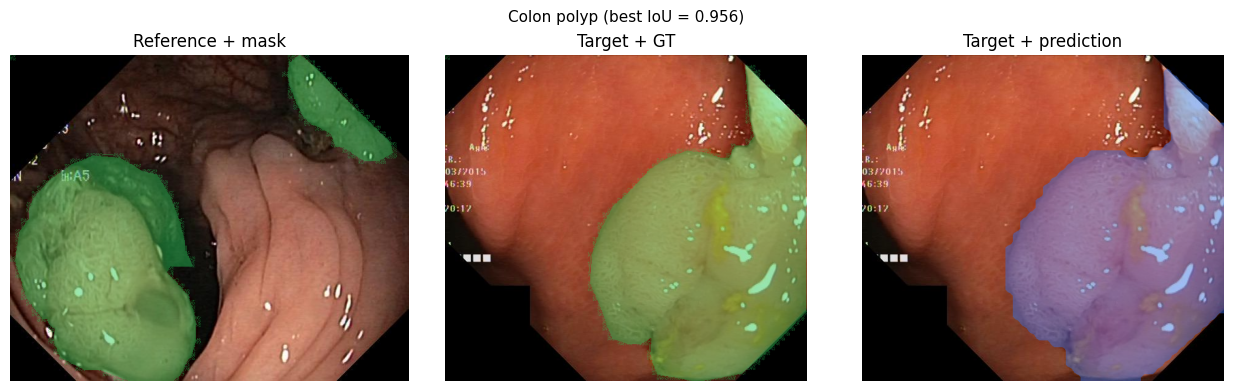

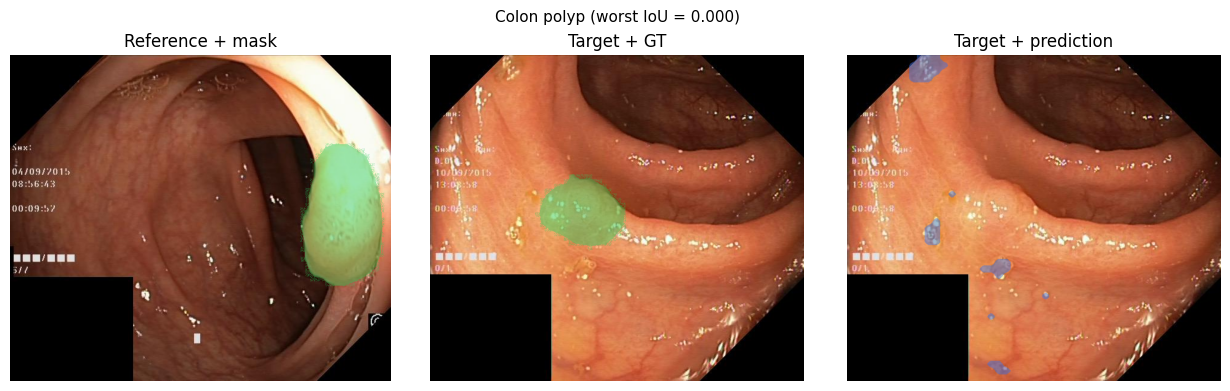

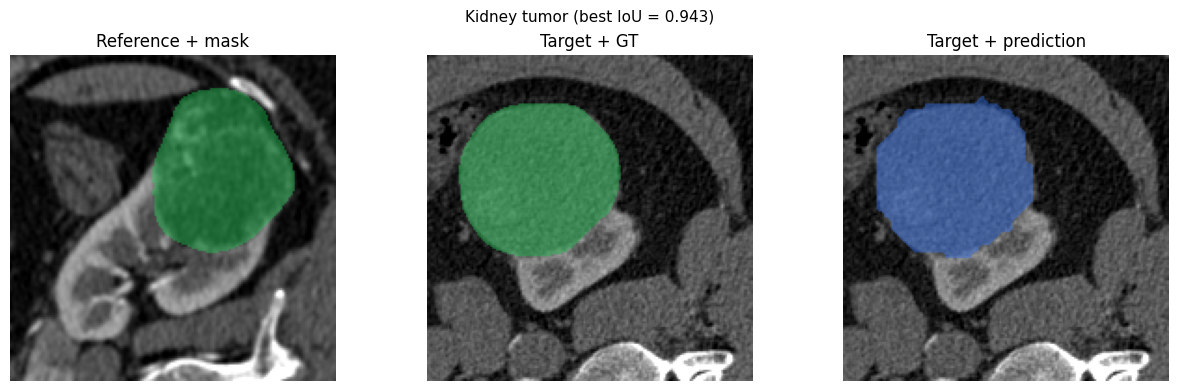

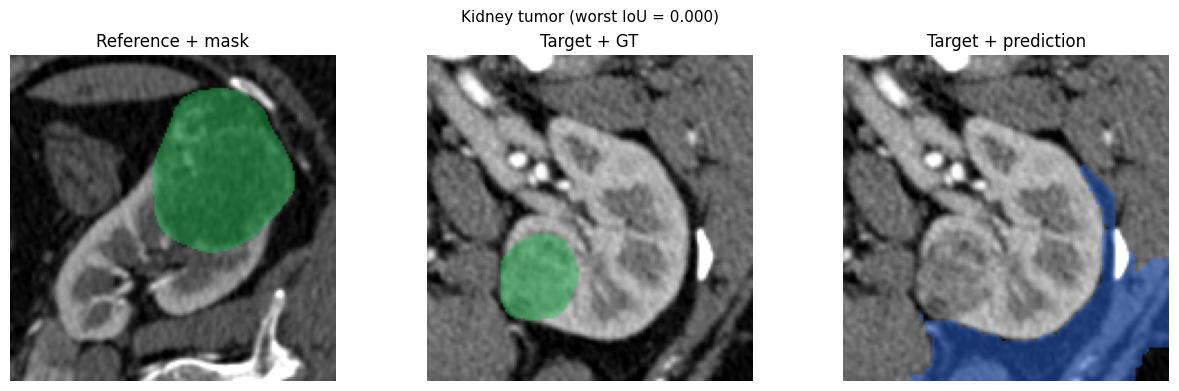

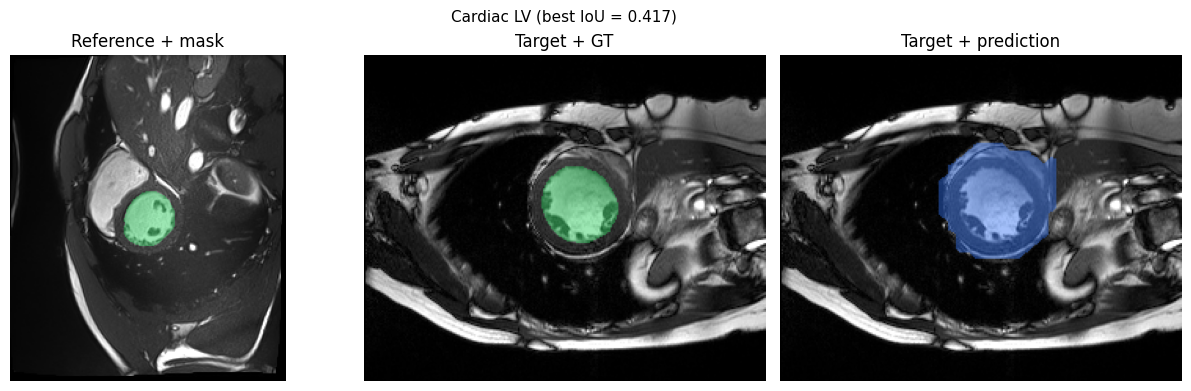

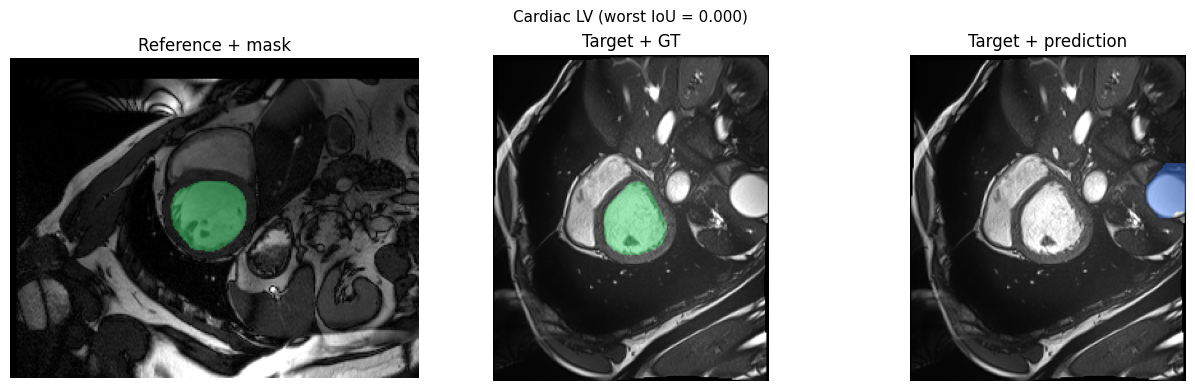

In [24]:
for name in found:
    pairs = load_paired_index(processed_root, name)
    _show_triple(name, domains[name]["ranked"][0], pairs, "best")
    _show_triple(name, domains[name]["ranked"][-1], pairs, "worst")

In [25]:
# KiPA image resolution ablation.
import json
from pathlib import Path

ABLATION_SIZE = 1024
metrics_768 = Path(DRIVE_ROOT) / "results" / "kidney_tumor" / "metrics.json"
ablation_root = Path(DRIVE_ROOT) / "results" / "kidney_tumor" / "1024"
metrics_1024 = ablation_root / "metrics.json"

if not metrics_768.is_file():
    raise FileNotFoundError("Run section 2 for kidney_tumor at 768 first.")

row_768 = json.loads(metrics_768.read_text())
row_1024 = json.loads(metrics_1024.read_text()) if metrics_1024.is_file() else None
already = (
    row_1024 is not None
    and int(row_1024.get("image_size", 0)) == ABLATION_SIZE
    and int(row_1024.get("n", 0)) == int(row_768["n"])
)

if already:
    print("skip kidney_tumor @ 1024 (already on Drive)")
else:
    log = "/tmp/insid3_eval_kidney_tumor_1024.log"
    print(f"kidney_tumor @ {ABLATION_SIZE} → {log}")
    !python src/run_insid3.py --dataset kidney_tumor \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {ablation_root} \
      --model-size {MODEL_SIZE} --image-size {ABLATION_SIZE} --seed {SEED} --device cuda \
      > {log}

row_1024 = json.loads(metrics_1024.read_text())
print(f"{'size':<8} {'n':>5} {'mIoU':>7} {'Dice':>7}")
print(f"{'768':<8} {int(row_768['n']):5d} {100 * row_768['mIoU']:6.1f}  {100 * row_768['Dice']:6.1f}")
print(f"{'1024':<8} {int(row_1024['n']):5d} {100 * row_1024['mIoU']:6.1f}  {100 * row_1024['Dice']:6.1f}")
print(f"Δ mIoU = {100 * (row_1024['mIoU'] - row_768['mIoU']):+.1f}")

kidney_tumor @ 1024 → /tmp/insid3_eval_kidney_tumor_1024.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
kidney_tumor: 100% 600/600 [05:59<00:00,  1.67it/s]
size         n    mIoU    Dice
768        600   30.6    43.2
1024       600   32.3    45.0
Δ mIoU = +1.7


**Cardiac 5-shot ablation.** 

In [26]:
# Cardiac 5-shot ablation (same-class LV, not multi-chamber).
import json
from pathlib import Path

SHOTS = 5
metrics_1 = Path(DRIVE_ROOT) / "results" / "cardiac" / "metrics.json"
ablation_root = Path(DRIVE_ROOT) / "results" / "cardiac" / "five-shot"
metrics_5 = ablation_root / "metrics.json"

if not metrics_1.is_file():
    raise FileNotFoundError("Run section 2 for cardiac (1-shot, 768) first.")

row_1 = json.loads(metrics_1.read_text())
row_5 = json.loads(metrics_5.read_text()) if metrics_5.is_file() else None
already = (
    row_5 is not None
    and int(row_5.get("shots", 0)) == SHOTS
    and int(row_5.get("n", 0)) == int(row_1["n"])
    and int(row_5.get("image_size", 0)) == int(IMAGE_SIZE)
    and int(row_5.get("seed", -1)) == int(SEED)
)

if already:
    print("skip cardiac 5-shot (already on Drive)")
else:
    log = "/tmp/insid3_eval_cardiac_5shot.log"
    print(f"cardiac 5-shot → {log}")
    !python src/run_insid3.py --dataset cardiac \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {ablation_root} \
      --model-size {MODEL_SIZE} --image-size {IMAGE_SIZE} --seed {SEED} \
      --shots {SHOTS} --device cuda \
      > {log}

row_5 = json.loads(metrics_5.read_text())
print(f"{'one-shot':<12} {int(row_1['n']):5d} {100 * row_1['mIoU']:6.1f}  {100 * row_1['Dice']:6.1f}")
print(f"{'5-shot':<12} {int(row_5['n']):5d} {100 * row_5['mIoU']:6.1f}  {100 * row_5['Dice']:6.1f}")
print(f"Δ mIoU = {100 * (row_5['mIoU'] - row_1['mIoU']):+.1f}")

cardiac 5-shot → /tmp/insid3_eval_cardiac_5shot.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
cardiac: 100% 600/600 [03:41<00:00,  2.71it/s]
one-shot       600   11.9    20.0
5-shot         600   11.8    19.9
Δ mIoU = -0.1


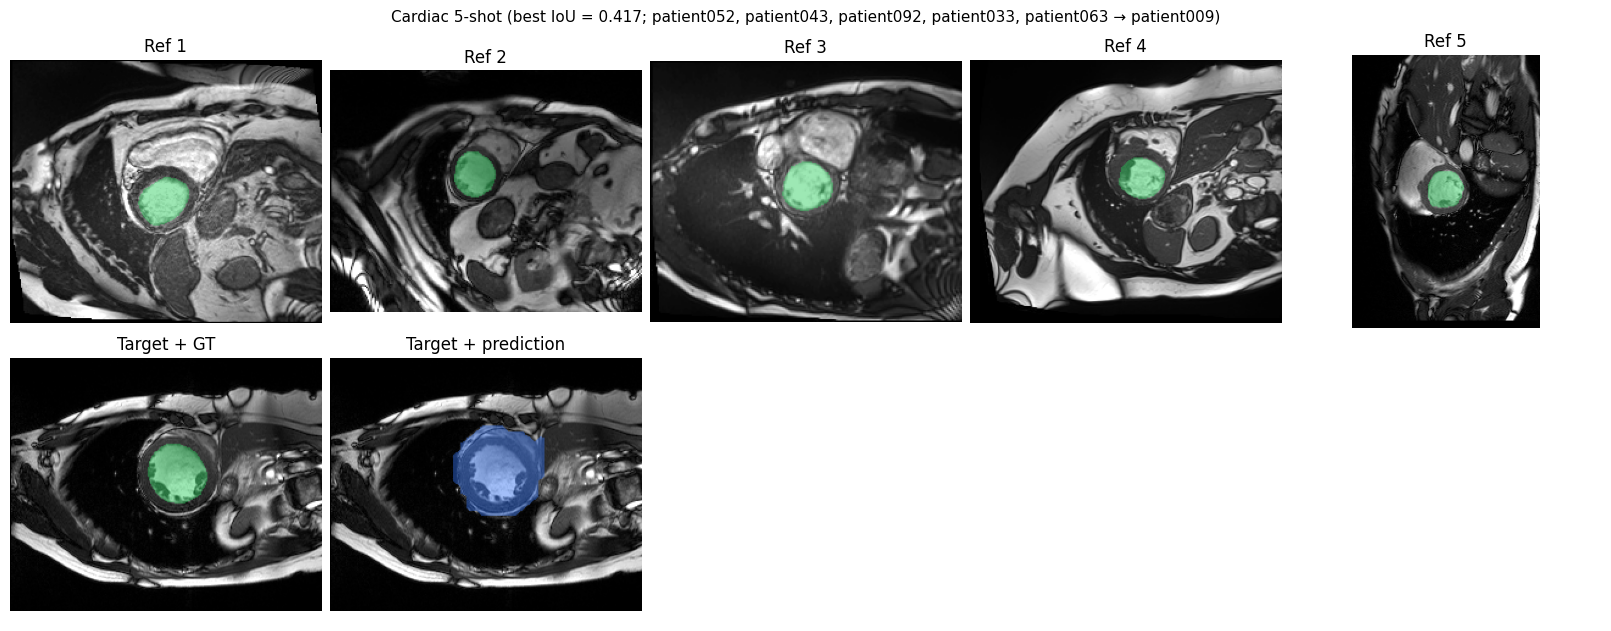

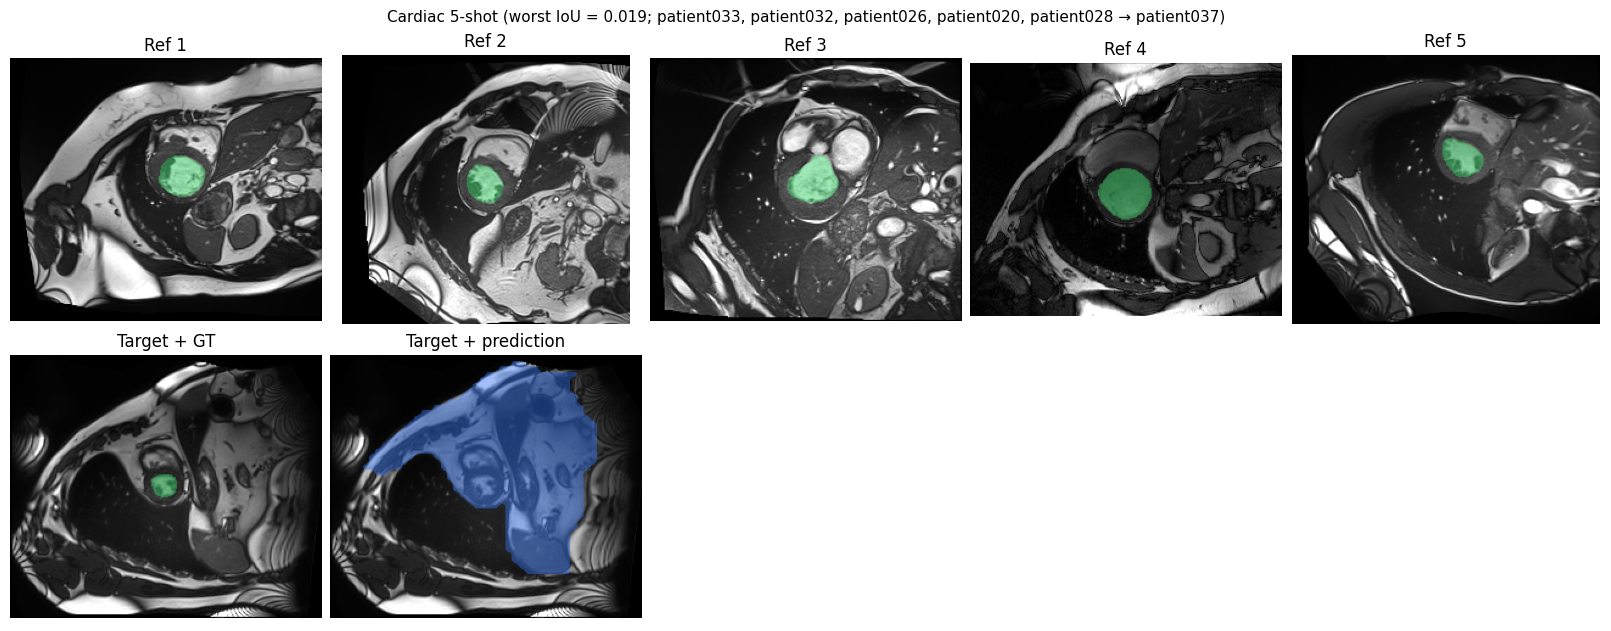

5-shot overlays from /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/five-shot/metrics.json


In [27]:
# Cardiac 5-shot overlays.
# All support images + masks, then target GT and prediction.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.datasets.episodes import load_paired_index

GT_GREEN = (0.15, 0.8, 0.35)
PRED_BLUE = (0.2, 0.45, 0.95)

ablation_root = Path(DRIVE_ROOT) / "results" / "cardiac" / "five-shot"
metrics_5 = ablation_root / "metrics.json"
if not metrics_5.is_file():
    raise FileNotFoundError("Run the cardiac 5-shot cell first.")

pairs = load_paired_index(Path(DRIVE_ROOT) / "processed", "cardiac")
payload = json.loads(metrics_5.read_text())
items = sorted(payload["items"], key=lambda row: row["IoU"], reverse=True)
pred_dir = ablation_root / "preds"


def _overlay(image, mask, color):
    out = image.astype(np.float32).copy()
    tint = np.array(color, dtype=np.float32) * 255.0
    out[mask] = 0.55 * out[mask] + 0.45 * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def _show_kshot(row, caption):
    ref_ids = list(row["reference_ids"])
    tgt_id = row["target_id"]
    pred_path = pred_dir / f"{int(row['episode_index']):04d}_{tgt_id}.png"
    tgt_img, tgt_mask = pairs[tgt_id]
    target_np = np.array(Image.open(tgt_img).convert("RGB"))
    gt = np.array(Image.open(tgt_mask).convert("L")) > 0
    pred = np.array(Image.open(pred_path).convert("L")) > 0 if pred_path.is_file() else np.zeros_like(gt)

    n_ref = len(ref_ids)
    n_cols = max(n_ref, 2)
    fig, axes = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 6.2), constrained_layout=True)
    for i, ref_id in enumerate(ref_ids):
        ref_img, ref_mask = pairs[ref_id]
        ref_np = np.array(Image.open(ref_img).convert("RGB"))
        ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
        axes[0, i].imshow(_overlay(ref_np, ref_gt, GT_GREEN))
        axes[0, i].set_title(f"Ref {i + 1}")
        axes[0, i].axis("off")
    for j in range(n_ref, n_cols):
        axes[0, j].axis("off")
    axes[1, 0].imshow(_overlay(target_np, gt, GT_GREEN))
    axes[1, 0].set_title("Target + GT")
    axes[1, 0].axis("off")
    axes[1, 1].imshow(_overlay(target_np, pred, PRED_BLUE))
    axes[1, 1].set_title("Target + prediction")
    axes[1, 1].axis("off")
    for j in range(2, n_cols):
        axes[1, j].axis("off")
    fig.suptitle(
        f"Cardiac 5-shot ({caption} IoU = {row['IoU']:.3f}; {', '.join(ref_ids)} → {tgt_id})",
        fontsize=11,
    )
    fig_dir = Path(DRIVE_ROOT) / "results" / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / f"cardiac_5shot_{caption}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


_show_kshot(items[0], "best")
_show_kshot(items[-1], "worst")
print(f"5-shot overlays from {metrics_5}")

**Interpretation**

**One-shot.** Under the same evaluation protocol, polyp obtains **67.8** mIoU, kidney tumor **30.6**, cardiac LV **11.9**. Polyp is the only strong transfer. Cardiac is the failure case.

**Image resolution.** DINOv3 ViT-L/16 is patch-16: 768 px is a 48×48 token grid, 1024 px is 64×64. Some kidney tumors are small foci on a full axial slice, so a lesion may occupy only a few tokens at 768. Rerunning the same 600 episodes at 1024 moved mIoU **30.6 → 32.3** (+1.7 pp). Extra tokens help a little and do not turn this into a working method.

**Does a larger mask make in-context segmentation easier?** The scatter of target area vs IoU tests that assumption, and the assumption is wrong. Kidney tumor is the only domain where smaller foci clearly score worse. Cardiac IoU stays low even though the LV cavity is large.

**Cardiac fails despite 5-shot learning.** Five other patients’ LV masks give **11.8** mIoU against one-shot **11.9**. More same-class examples do not improve LV segmentation: on a short-axis frame both blood pools look like the reference. Overlays (green = GT, blue = prediction) typically hit the RV, the whole heart, or nothing. 

<h2 id="sec-inspect">4. Inspect episodes</h2>

The slider ranks episodes from best to worst IoU so you can see, case by case, whether the prediction matches the target or lands on the wrong structure. 

In [6]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ipywidgets import IntSlider, interact

from src.datasets.episodes import load_paired_index

DATASET = "cardiac"  # polyp | kidney_tumor | cardiac
RESULTS = Path(DRIVE_ROOT) / "results" / DATASET  # headline 1-shot
# Cardiac 5-shot (all support images):
# RESULTS = Path(DRIVE_ROOT) / "results" / "cardiac" / "five-shot"
# Older 5-shot folder, if that is what is on Drive:
# RESULTS = Path(DRIVE_ROOT) / "results" / "cardiac_5shot" / "cardiac"

_pairs = load_paired_index(Path(DRIVE_ROOT) / "processed", DATASET)
_metrics_path = RESULTS / "metrics.json"
_pred_dir = RESULTS / "preds"


def _overlay(image: np.ndarray, mask: np.ndarray, color: tuple[float, float, float]) -> np.ndarray:
    out = image.astype(np.float32).copy()
    tint = np.array(color, dtype=np.float32) * 255.0
    out[mask] = 0.55 * out[mask] + 0.45 * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def _load_metrics():
    if not _metrics_path.is_file():
        raise FileNotFoundError(
            f"{_metrics_path} missing — run section 2, or point RESULTS at an ablation folder."
        )
    payload = json.loads(_metrics_path.read_text())
    items = sorted(payload["items"], key=lambda row: row["IoU"], reverse=True)
    return payload, items


def show_episode(rank: int = 0):
    """rank=0 is the best IoU. GT masks are green; prediction is blue."""
    payload, items = _load_metrics()
    row = items[int(rank)]
    ref_ids = list(row["reference_ids"])
    tgt_id = row["target_id"]
    pred_path = _pred_dir / f"{int(row['episode_index']):04d}_{tgt_id}.png"
    tgt_img, tgt_mask = _pairs[tgt_id]

    print(
        f"{payload.get('dataset')}  rank {int(rank)+1}/{len(items)}  "
        f"ep {row['episode_index']}: {', '.join(ref_ids)} → {tgt_id}  "
        f"IoU={row['IoU']:.3f}  Dice={row['Dice']:.3f}"
    )

    target_np = np.array(Image.open(tgt_img).convert("RGB"))
    gt = np.array(Image.open(tgt_mask).convert("L")) > 0
    pred = np.array(Image.open(pred_path).convert("L")) > 0

    n_ref = len(ref_ids)
    if n_ref == 1:
        fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
        ref_img, ref_mask = _pairs[ref_ids[0]]
        ref_np = np.array(Image.open(ref_img).convert("RGB"))
        ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
        axes[0].imshow(_overlay(ref_np, ref_gt, (0.15, 0.8, 0.35)))
        axes[0].set_title("Reference + mask")
        axes[1].imshow(_overlay(target_np, gt, (0.15, 0.8, 0.35)))
        axes[1].set_title("Target + GT")
        axes[2].imshow(_overlay(target_np, pred, (0.2, 0.45, 0.95)))
        axes[2].set_title("Target + prediction")
        for ax in axes:
            ax.axis("off")
    else:
        n_cols = max(n_ref, 2)
        fig, axes = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 6.2), constrained_layout=True)
        for i, ref_id in enumerate(ref_ids):
            ref_img, ref_mask = _pairs[ref_id]
            ref_np = np.array(Image.open(ref_img).convert("RGB"))
            ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
            axes[0, i].imshow(_overlay(ref_np, ref_gt, (0.15, 0.8, 0.35)))
            axes[0, i].set_title(f"Ref {i + 1}")
            axes[0, i].axis("off")
        for j in range(n_ref, n_cols):
            axes[0, j].axis("off")
        axes[1, 0].imshow(_overlay(target_np, gt, (0.15, 0.8, 0.35)))
        axes[1, 0].set_title("Target + GT")
        axes[1, 0].axis("off")
        axes[1, 1].imshow(_overlay(target_np, pred, (0.2, 0.45, 0.95)))
        axes[1, 1].set_title("Target + prediction")
        axes[1, 1].axis("off")
        for j in range(2, n_cols):
            axes[1, j].axis("off")
    plt.show()
    plt.close(fig)


payload, items = _load_metrics()
print(f"{DATASET}: {len(items)} episodes from {_metrics_path}")
show_episode(0)

KeyError: "unknown dataset 'cardiac_5shot'; expected one of ['cardiac', 'kidney_tumor', 'polyp']"

In [15]:
# Drag to browse the current DATASET. 0 = best IoU. Does not persist on GitHub.
_, items = _load_metrics()
interact(
    show_episode,
    rank=IntSlider(min=0, max=max(len(items) - 1, 0), step=1, value=0, description="best→worst"),
)

interactive(children=(IntSlider(value=0, description='best→worst', max=599), Output()), _dom_classes=('widget-…

<function __main__.show_episode(rank: int = 0)>

<h2 id="sec-refs">References</h2>

<p id="ref-cuttano2026">[1] C. Cuttano, G. Trivigno, C. Reich, D. Cremers, C. Masone, and S. Roth. INSID3: Training-free in-context segmentation with DINOv3. In <em>Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)</em>, 2026. <a href="https://visinf.github.io/INSID3/">project page</a>.</p>

<p id="ref-simeoni2025">[2] O. Siméoni, H. V. Vo, M. Seitzer, F. Baldassarre, M. Oquab, C. Jose, V. Khalidov, M. Szafraniec, S. Yi, M. Ramamonjisoa, et al. DINOv3. <em>arXiv preprint arXiv:2508.10104</em>, 2025.</p>

<p id="ref-jha2020">[3] D. Jha, P. H. Smedsrud, M. A. Riegler, P. Halvorsen, T. de Lange, D. Johansen, and H. D. Johansen. Kvasir-SEG: A segmented polyp dataset. In <em>International Conference on Multimedia Modeling (MMM)</em>, 2020. <a href="https://datasets.simula.no/kvasir-seg/">Kvasir-SEG</a>.</p>

<p id="ref-he2021">[4] Y. He, G. Yang, J. Yang, R. Chen, J. L. Coatrieux, and S. Li. Dense biased networks with deep priori anatomy and hard region adaptation: Semi-supervised learning for fine renal artery segmentation. <em>Medical Image Analysis</em>, 2021. Training data: <a href="https://kipa22.grand-challenge.org/">KiPA22</a>.</p>

<p id="ref-bernard2018">[5] O. Bernard, A. Lalande, C. Zotti, F. Cervenansky, X. Yang, P.-A. Heng, I. Cetin, K. Lekadir, O. Camara, M. A. Gonzalez Ballester, et al. Deep learning techniques for automatic MRI cardiac multi-structures segmentation and diagnosis: Is the problem solved? <em>IEEE Transactions on Medical Imaging</em>, 2018. <a href="https://www.creatis.insa-lyon.fr/Challenge/acdc/">ACDC</a>.</p>